# RAG implementation
- RAG is created as a seperate tool

In [1]:
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import START, END, StateGraph
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition


/Users/ritumalage/Documents/my_github/Notes/.venv_langgraph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = ChatGroq(model = "qwen/qwen3-32b") 

# Load the PDF

In [3]:
loader = PyPDFLoader("./utils/langgraph.pdf")
docs = loader.load()

# Split the PDF

In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
chunks = splitter.split_documents(docs)

# Embed each document, and store it in the vectorDB

In [10]:
from langchain_community.embeddings import HuggingFaceEmbeddings
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = FAISS.from_documents(chunks, embedding_model)



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8059.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Creating the retriever objects

In [11]:
retriever = vector_store.as_retriever(search_type = "similarity", search_kwargs = {"k": 4})


# Creating the RAG tool

In [12]:
@tool
def rag_tool(query):
    """
    Answers the given query based on the document shared. Use this tool when user wants a very sepcific information thats related to the document passed, or stored
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query": query,
        "context": context,
        "metadata": metadata
    }

In [13]:
tools = [rag_tool]
model_with_tools = model.bind_tools(tools)


In [14]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [15]:
def chat_node(state: State):
    message = state["messages"]
    response = model_with_tools.invoke(message)
    return {"messages": [response]}

In [16]:
tool_node = ToolNode(tools)

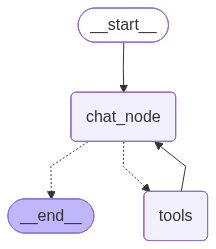

In [17]:
graph = StateGraph(State)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

workflow = graph.compile()
workflow

In [18]:
initial_state = {"messages": [HumanMessage(content = "What are the core concepts in langgraph?")]}
workflow.invoke(initial_state)

{'messages': [HumanMessage(content='What are the core concepts in langgraph?', additional_kwargs={}, response_metadata={}, id='afcedf36-a022-4146-bffe-6723a057fe74'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the core concepts in LangGraph. I need to figure out how to approach this. Since the user mentioned "core concepts," they probably want an overview of the fundamental ideas or components that make up LangGraph.\n\nFirst, I should check if there\'s a document or resource that explains LangGraph\'s structure. The available tool is the rag_tool, which is for retrieving specific information from a document. But the user isn\'t asking for a very specific detail; they want core concepts. However, since the tool is designed for when the user needs info related to a document, maybe the answer is in the provided document. \n\nI don\'t have prior knowledge about LangGraph beyond what\'s in the document. So, I should use the rag_tool to q